In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm

Скачиваем данные

In [18]:
file_name = "DTBSPCKNMM.xlsx" # Путь к файлу

df = pd.read_excel(file_name, sheet_name="Данные")

print(df.head()) 
print(df.info()) 

           Ряд
0  1559.985460
1  1535.198787
2  1532.362414
3  1541.506571
4  1501.050752
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ряд     302 non-null    float64
dtypes: float64(1)
memory usage: 2.5 KB
None


Строим график

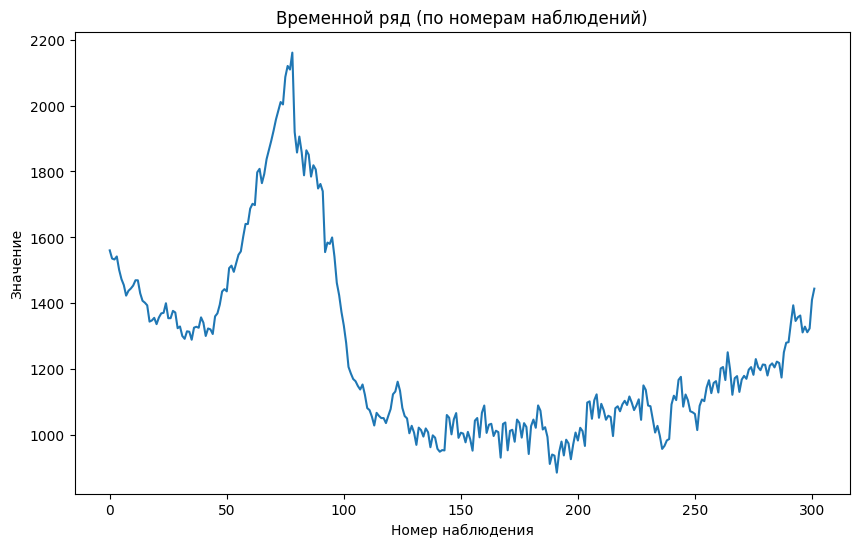

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Ряд'], linestyle="-")
plt.title("Временной ряд (по номерам наблюдений)")
plt.xlabel("Номер наблюдения")
plt.ylabel("Значение")
plt.show()

Строим вторую разность

In [20]:
df["diff_1"] = df["Ряд"].diff()
df["diff_2"] = df["diff_1"].diff()

df

,Ряд,diff_1,diff_2
0,1559.985460,NaN,NaN
1,1535.198787,-24.786672,NaN
2,1532.362414,-2.836373,21.950299
3,1541.506571,9.144157,11.980530
4,1501.050752,-40.455819,-49.599975
...,...,...,...
297,1328.313751,17.519998,68.885069
298,1311.320480,-16.993270,-34.513268
299,1322.878112,11.557632,28.550902
300,1409.571023,86.692911,75.135280


Строим график второй разности

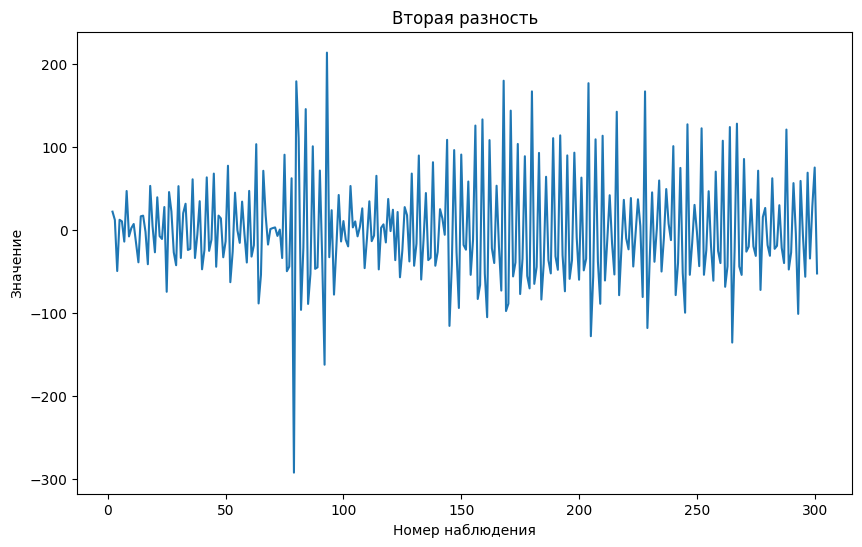

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['diff_2'], linestyle="-")
plt.title("Вторая разность")
plt.xlabel("Номер наблюдения")
plt.ylabel("Значение")
plt.show()

Проведем тест на стационарность

In [22]:
series = df["diff_2"].dropna()

result = adfuller(series, autolag="AIC")

adf_stat = result[0]
p_value = result[1]

print(f"ADF-статистика: {adf_stat:.4f}")
print(f"p-значение: {p_value:.4f}")

ADF-статистика: -6.4970
p-значение: 0.0000


Ряд стационарен

Построим график авкокорреляции

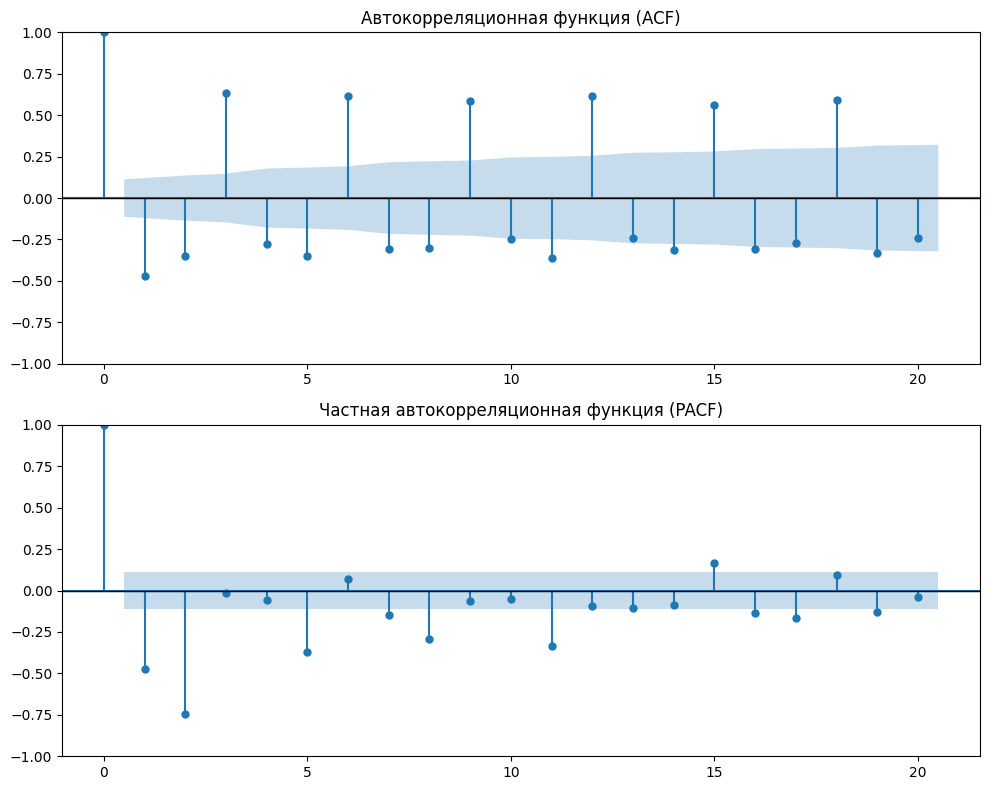

In [23]:
series = df["diff_2"].dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(series, lags=min(20, len(series) - 1), ax=ax[0], title="Автокорреляционная функция (ACF)")
ax[0].axhline(0, color="black", linewidth=1)

plot_pacf(series, lags=min(20, len(series) - 1), ax=ax[1], title="Частная автокорреляционная функция (PACF)", method="yw")
ax[1].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

Построим модель AR(2)

In [24]:
series = df['diff_2'].dropna().copy()

series.index = pd.RangeIndex(start=0, stop=len(series), step=1)

model = sm.tsa.ARIMA(series, order=(2, 0, 0), trend='n')
fit = model.fit()

print(fit.summary())

resid = fit.resid

                               SARIMAX Results                                
Dep. Variable:                 diff_2   No. Observations:                  300
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1522.584
Date:                Fri, 03 Jul 2026   AIC                           3051.168
Time:                        22:25:36   BIC                           3062.279
Sample:                             0   HQIC                          3055.614
                                - 300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8194      0.040    -20.302      0.000      -0.898      -0.740
ar.L2         -0.7361      0.029    -25.140      0.000      -0.794      -0.679
sigma2      1498.6341     57.974     25.850      0.0

Тестирование модели на ARCH-эффекты

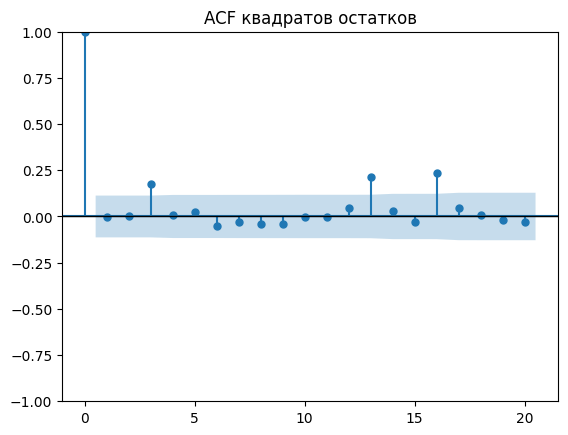

In [25]:
plot_acf(resid**2, lags=20, title='ACF квадратов остатков')
plt.axhline(0, color='black', linewidth=1)
plt.show()

In [26]:
lb_test = acorr_ljungbox(resid**2, lags=1, return_df=True)
print(lb_test)

    lb_stat  lb_pvalue
1  0.007674   0.930192


ARCH-эффектов нет

Построим прогноз модели, вернемся к уровню ряда и построим график с доверительными интервалами

Параметры модели:
ar.L1       -0.819354
ar.L2       -0.736125
sigma2    1498.634122
dtype: float64

Прогноз исходного ряда (аналитические ДИ, AR(2) на diff_2):
        Прогноз (среднее)  Нижняя граница (95%)  Верхняя граница (95%)  \
Период                                                                   
1             1465.640291           1389.940222            1541.340360   
2             1536.256781           1419.131231            1653.382330   
3             1575.991316           1423.181035            1728.801596   
4             1605.164999           1386.367480            1823.962518   
5             1665.724736           1383.700346            1947.749127   
6             1708.342307           1366.530222            2050.154392   

        Стд. ошибка прогноза  
Период                        
1                  38.623194  
2                  59.759031  
3                  77.965862  
4                 111.633438  
5                 143.892639  
6                 174.397125  

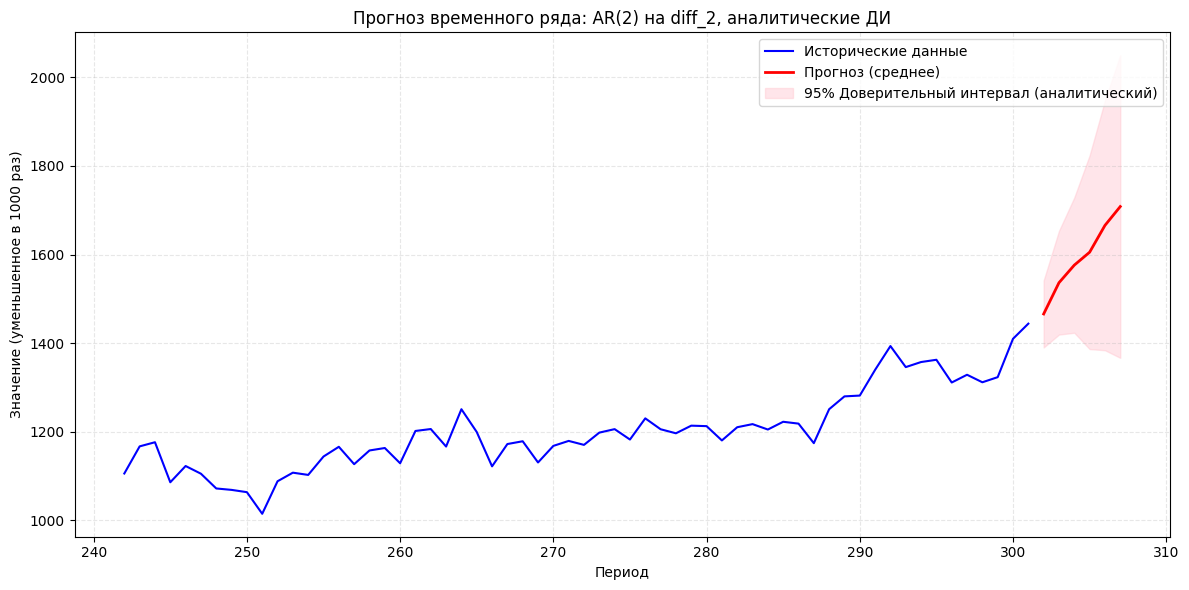

In [27]:
series = df['diff_2'].dropna().copy()
series.index = pd.RangeIndex(start=0, stop=len(series), step=1)

model = sm.tsa.ARIMA(series, order=(2, 0, 0), trend='n')
fit = model.fit()

print("Параметры модели:")
print(fit.params)

resid = fit.resid
sigma2 = np.var(resid, ddof=0)
phi = np.array([fit.params['ar.L1'], fit.params['ar.L2']])

lag1 = series.iloc[-1]
lag2 = series.iloc[-2]
last_y = df['Ряд'].iloc[-1]
last_diff1 = df['diff_1'].iloc[-1]

h = 6
forecasts_ar = np.zeros(h)         
var_ar = np.zeros(h)               

def arma_forecast_variance(phi, sigma2, h):
    p = len(phi)
    psi = np.zeros(h + p) 
    psi[0] = 1.0

    for j in range(1, h + p):
        s = 0.0
        for k in range(1, p + 1):
            if j - k >= 0:
                s += phi[k - 1] * psi[j - k]
        psi[j] = s

    var_h = np.zeros(h)
    for hh in range(1, h + 1):
        var_h[hh - 1] = sigma2 * np.sum(psi[:hh]**2)
    return var_h


var_ar = arma_forecast_variance(phi, sigma2, h)


l1, l2 = lag1, lag2
for i in range(h):
    forecasts_ar[i] = phi[0] * l1 + phi[1] * l2
    l2 = l1
    l1 = forecasts_ar[i]


psi = np.zeros(h + 2)
psi[0] = 1.0
p = 2
for j in range(1, h + 2):
    s = 0.0
    for k in range(1, p + 1):
        if j - k >= 0:
            s += phi[k - 1] * psi[j - k]
    psi[j] = s


cov_d2 = np.zeros((h, h))
for i in range(h):
    for j in range(h):
        k = abs(i - j)
        m_max = min(i, j)
        cov_d2[i, j] = sigma2 * np.sum([psi[m] * psi[m + k] for m in range(m_max + 1)])


c = np.arange(h, 0, -1).astype(float)

mean_forecast = np.zeros(h)
var_forecast = np.zeros(h)


cum_c = 0.0
for hh in range(1, h + 1):
    c_hh = np.arange(hh, 0, -1).astype(float)
    mean_forecast[hh - 1] = last_y + hh * last_diff1 + np.dot(c_hh, forecasts_ar[:hh])
    var_forecast[hh - 1] = c_hh @ cov_d2[:hh, :hh] @ c_hh


std_forecast = np.sqrt(var_forecast)
z = norm.ppf(0.975)  
lower_95 = mean_forecast - z * std_forecast
upper_95 = mean_forecast + z * std_forecast


forecast_df = pd.DataFrame({
    'Прогноз (среднее)': mean_forecast,
    'Нижняя граница (95%)': lower_95,
    'Верхняя граница (95%)': upper_95,
    'Стд. ошибка прогноза': std_forecast
}, index=range(1, h+1))
forecast_df.index.name = 'Период'

print("\nПрогноз исходного ряда (аналитические ДИ, AR(2) на diff_2):")
print(forecast_df)


plt.figure(figsize=(12, 6))
hist_len = min(60, len(df))
plt.plot(df.index[-hist_len:], df['Ряд'].iloc[-hist_len:],
         label='Исторические данные', color='blue')

forecast_x = np.arange(len(df), len(df)+h)
plt.plot(forecast_x, mean_forecast, label='Прогноз (среднее)', color='red', linewidth=2)
plt.fill_between(forecast_x, lower_95, upper_95,
                 color='pink', alpha=0.4, label='95% Доверительный интервал (аналитический)')

plt.title('Прогноз временного ряда: AR(2) на diff_2, аналитические ДИ')
plt.xlabel('Период')
plt.ylabel('Значение (уменьшенное в 1000 раз)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Скачаем новые данные

In [29]:
df_new = pd.read_excel(file_name, sheet_name="Новый ряд")
df_new[-4:]

,Новый ряд
302,1.388349e+06
303,1.457290e+06
304,1.458170e+06
305,1.412976e+06


Мы видим, что все значения предсказаний, кроме первого входят в доверительный интервал, соответственно, наша модель работает неплохо